# Olist E-commerce: Delivery Performance, Customer Value and Satisfaction
**Data:** Olist public e-commerce dataset (real, anonymised orders from a Brazilian marketplace, 2016-2018).
**Method:** all numbers come from the SQL files in `/sql` (single source of truth), pulled into pandas for charts and statistics.

**Questions**
1. How did the business grow, and what do the peaks tell us?
2. Where and when does delivery fail?
3. Does late delivery really hurt satisfaction, and is it still true once other factors are controlled?
4. Where does revenue concentrate (categories, sellers)?
5. What does the customer base look like (RFM), and does a bad first order cost a repeat purchase?

In [1]:
import re, json
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
con = duckdb.connect(str(ROOT / "data" / "olist.duckdb"), read_only=True)
CH = ROOT / "outputs" / "charts"; CH.mkdir(parents=True, exist_ok=True)

def q(sql):
    return con.execute(sql).df()

def named(file, name):
    """Run one named query block from a file in /sql, so SQL stays the single source of truth."""
    text = (ROOT / "sql" / file).read_text()
    parts = re.split(r"^-- name:\s*(\S+)\s*$", text, flags=re.M)
    blocks = {parts[i]: parts[i + 1].strip().rstrip(";") for i in range(1, len(parts), 2)}
    return con.execute(blocks[name]).df()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY, GREEN = "#2b6cb0", "#c53030", "#a0aec0", "#2f855a"
KEY = {}   # headline numbers, saved at the end for the README

def save(name):
    plt.tight_layout()
    plt.savefig(CH / name, dpi=150, bbox_inches="tight")
    plt.show()

## 1. Growth: strong 2017, flat 2018

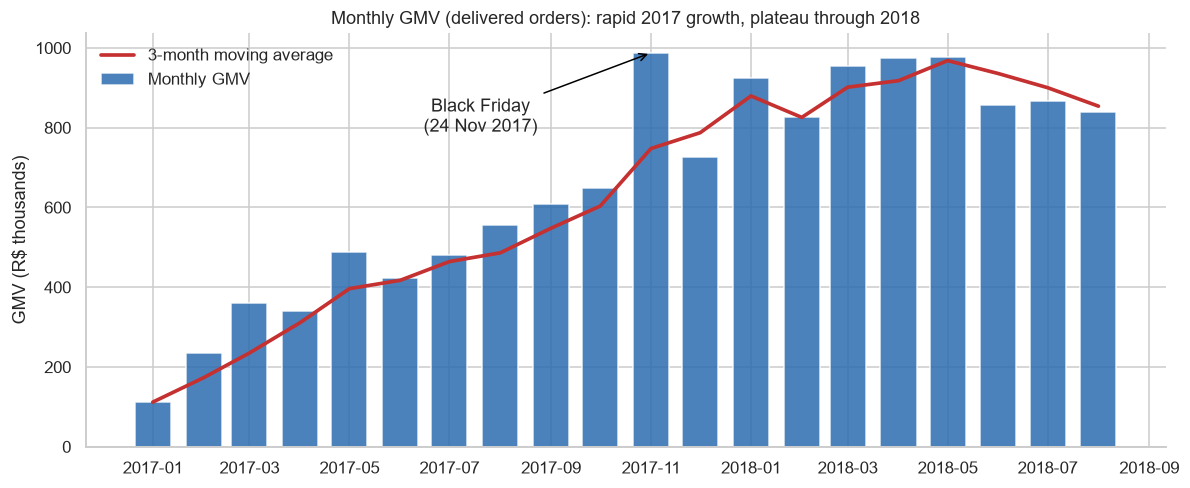

Jan-Aug 2018 vs Jan-Aug 2017: orders +139.9%, GMV +141.1%
2018 monthly GMV stayed within R$ 826,437 to 977,545


In [2]:
m = named("03_revenue_trends.sql", "monthly_revenue")
m["month"] = pd.to_datetime(m["month"])

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(m["month"], m["gmv"] / 1e3, width=22, color=BLUE, alpha=.85, label="Monthly GMV")
ax.plot(m["month"], m["gmv_3m_moving_avg"] / 1e3, color=RED, lw=2.4, label="3-month moving average")
nov = m.loc[m["month"] == "2017-11-01"].iloc[0]
ax.annotate("Black Friday\n(24 Nov 2017)", xy=(nov["month"], nov["gmv"] / 1e3),
            xytext=(pd.Timestamp("2017-07-20"), 790), ha="center",
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_ylabel("GMV (R$ thousands)")
ax.set_title("Monthly GMV (delivered orders): rapid 2017 growth, plateau through 2018")
ax.legend(frameon=False, loc="upper left")
save("01_monthly_gmv.png")

yoy = named("03_revenue_trends.sql", "year_over_year_jan_aug").iloc[0]
KEY["yoy_gmv_growth_pct"] = float(yoy["gmv_growth_pct"])
KEY["yoy_orders_growth_pct"] = float(yoy["orders_growth_pct"])
KEY["gmv_total"] = float(m["gmv"].sum())
plateau = m[m["month"] >= "2018-01-01"]["gmv"]
KEY["gmv_2018_monthly_min"], KEY["gmv_2018_monthly_max"] = float(plateau.min()), float(plateau.max())
print(f"Jan-Aug 2018 vs Jan-Aug 2017: orders +{yoy['orders_growth_pct']}%, GMV +{yoy['gmv_growth_pct']}%")
print(f"2018 monthly GMV stayed within R$ {plateau.min():,.0f} to {plateau.max():,.0f}")

In [3]:
pk = named("03_revenue_trends.sql", "peak_days")
typical = q("SELECT median(c) FROM (SELECT count(*) c FROM v_analysis_orders WHERE purchased_at >= '2017-10-01' AND purchased_at < '2017-11-20' GROUP BY CAST(purchased_at AS DATE))").iloc[0, 0]
bf = int(pk.iloc[0]["orders"])
KEY["black_friday_orders"], KEY["typical_day_orders_oct_nov17"] = bf, float(typical)
print(f"Black Friday 2017: {bf:,} orders in one day = {bf/typical:.1f}x a typical day in the weeks before")
pk

Black Friday 2017: 1,147 orders in one day = 7.5x a typical day in the weeks before


,day,orders,gmv
0,2017-11-24,1147,149917.0
1,2017-11-25,487,59929.0
2,2017-11-27,395,47237.0
3,2017-11-26,382,44000.0
4,2017-11-28,371,47577.0
5,2018-08-06,363,53475.0
6,2018-05-07,363,52726.0
7,2018-05-14,355,52633.0
8,2018-08-07,353,46744.0
9,2018-05-16,351,55562.0


## 2. Delivery: where and when does it fail?

In [4]:
ov = named("04_delivery_performance.sql", "overall_delivery").iloc[0]
st = named("04_delivery_performance.sql", "delivery_stage_breakdown").iloc[0]
KEY.update(late_pct=float(ov["late_pct"]), avg_delivery_days=float(ov["avg_delivery_days"]),
           avg_promised_days=float(ov["avg_promised_days"]),
           pct_week_early=float(ov["pct_delivered_a_week_early"]),
           seller_handling_days=float(st["approval_to_carrier_days"]),
           transit_days=float(st["carrier_to_customer_days"]))
print(f"Late: {ov['late_pct']}% | actual {ov['avg_delivery_days']} days vs promised {ov['avg_promised_days']} days | "
      f"{ov['pct_delivered_a_week_early']}% arrive 7+ days before the promised date")
print(f"Time split: seller handling {st['approval_to_carrier_days']} d, carrier transit {st['carrier_to_customer_days']} d")

Late: 6.79% | actual 12.5 days vs promised 23.6 days | 78.9% arrive 7+ days before the promised date
Time split: seller handling 2.82 d, carrier transit 9.37 d


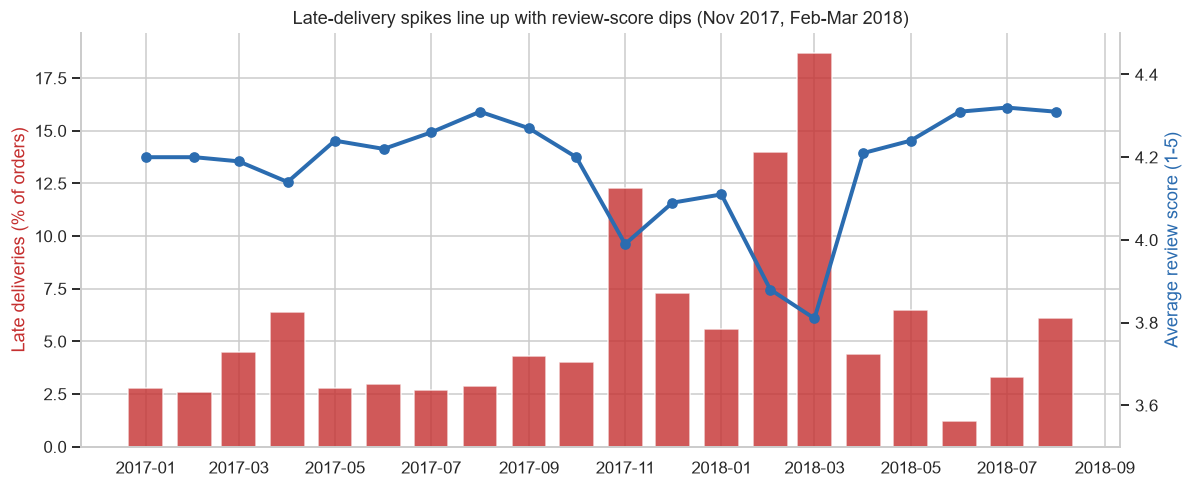

Monthly correlation (late % vs avg score): -0.92


In [5]:
ml = named("07_satisfaction_drivers.sql", "monthly_score_vs_late")
ml["month"] = pd.to_datetime(ml["month"])
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(ml["month"], ml["late_pct"], width=22, color=RED, alpha=.8, label="Late deliveries (%)")
ax.set_ylabel("Late deliveries (% of orders)", color=RED)
ax2 = ax.twinx()
ax2.plot(ml["month"], ml["avg_score"], color=BLUE, lw=2.6, marker="o", label="Average review score")
ax2.set_ylim(3.5, 4.5); ax2.set_ylabel("Average review score (1-5)", color=BLUE)
ax2.spines["right"].set_visible(True); ax2.grid(False)
ax.set_title("Late-delivery spikes line up with review-score dips (Nov 2017, Feb-Mar 2018)")
save("02_late_vs_score_monthly.png")
print("Monthly correlation (late % vs avg score):", round(ml["late_pct"].corr(ml["avg_score"]), 2))
KEY["monthly_corr_late_vs_score"] = float(ml["late_pct"].corr(ml["avg_score"]))

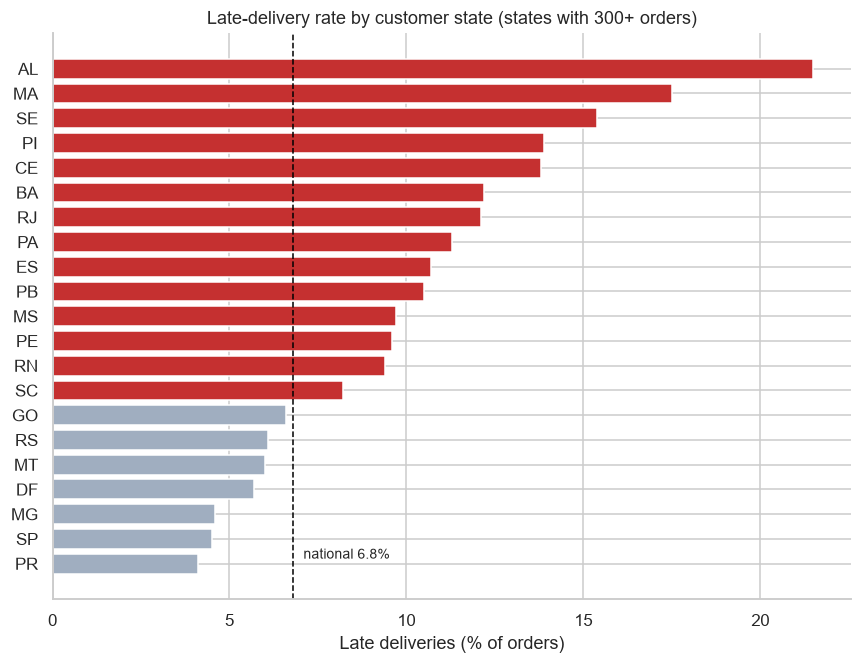

      route  orders  pct_of_orders  avg_delivery_days  late_pct  avg_freight  freight_pct_of_item_value
cross-state   60782           64.0               15.2       8.2         26.6                       18.2
 same state   34149           36.0                7.9       4.6         15.2                       12.8


In [6]:
sd = named("04_delivery_performance.sql", "state_delivery_ranking").sort_values("late_pct")
nat = KEY["late_pct"]
fig, ax = plt.subplots(figsize=(8, 6.2))
ax.barh(sd["customer_state"], sd["late_pct"], color=[RED if v > nat else GREY for v in sd["late_pct"]])
ax.axvline(nat, color="black", ls="--", lw=1); ax.text(nat + .3, 0.2, f"national {nat:.1f}%", fontsize=9)
ax.set_xlabel("Late deliveries (% of orders)")
ax.set_title("Late-delivery rate by customer state (states with 300+ orders)")
save("03_late_by_state.png")

rt = named("04_delivery_performance.sql", "same_state_vs_cross_state")
print(rt.to_string(index=False))
KEY["cross_state_pct_orders"] = float(rt.loc[rt.route == "cross-state", "pct_of_orders"].iloc[0])
KEY["cross_state_days"] = float(rt.loc[rt.route == "cross-state", "avg_delivery_days"].iloc[0])
KEY["same_state_days"] = float(rt.loc[rt.route == "same state", "avg_delivery_days"].iloc[0])

In [7]:
dist = named("04_delivery_performance.sql", "seller_late_distribution")
print(dist.to_string(index=False))
print("\nTakeaway: lateness is spread across the middle of the seller base, not concentrated in a few bad sellers.")

     seller_band  sellers  orders  late_orders  pct_of_all_late_orders
1) under 5% late      180 24512.0        799.0                    16.1
   2) 5-10% late      163 38494.0       2786.0                    56.0
  3) 10-20% late       77 10485.0       1314.0                    26.4
    4) 20%+ late        4   310.0         74.0                     1.5

Takeaway: lateness is spread across the middle of the seller base, not concentrated in a few bad sellers.


## 3. Does late delivery hurt satisfaction?
Descriptive first, then a significance test, then a regression to check the effect survives controls.

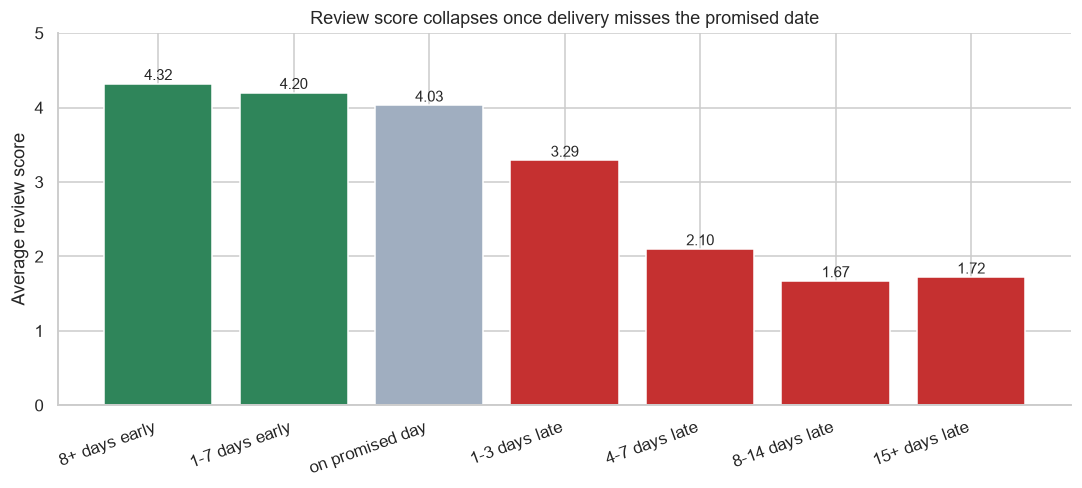

,delivery_vs_promise,orders,avg_score,pct_1_2_star,pct_5_star
0,1) 8+ days early,70673,4.32,9.0,63.7
1,2) 1-7 days early,17229,4.20,10.2,57.5
2,3) on promised day,1280,4.03,12.4,50.6
3,4) 1-3 days late,1851,3.29,32.1,33.2
4,5) 4-7 days late,1748,2.10,67.7,14.1
5,6) 8-14 days late,1446,1.67,80.2,6.8
6,7) 15+ days late,1333,1.72,78.3,7.2


In [8]:
sl = named("07_satisfaction_drivers.sql", "score_by_lateness")
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [GREEN, GREEN, GREY, RED, RED, RED, RED]
ax.bar(sl["delivery_vs_promise"].str[3:], sl["avg_score"], color=colors)
for i, v in enumerate(sl["avg_score"]):
    ax.text(i, v + .05, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylim(0, 5); ax.set_ylabel("Average review score")
ax.set_title("Review score collapses once delivery misses the promised date")
plt.xticks(rotation=20, ha="right")
save("04_score_by_lateness.png")
sl

In [9]:
df = q("""SELECT review_score, is_late, delivery_days, promised_days, days_late,
                  items_value, freight_value, n_sellers
           FROM v_analysis_orders
           WHERE review_score IS NOT NULL AND items_value > 0""")
late, ontime = df.loc[df.is_late == 1, "review_score"], df.loc[df.is_late == 0, "review_score"]

# 1) Mann-Whitney U: review scores are ordinal (1-5), so a rank test is the appropriate choice
u, p = stats.mannwhitneyu(late, ontime, alternative="two-sided")
p_superiority = 1 - u / (len(late) * len(ontime))        # P(late order scores lower than on-time order), ties split
# 2) Difference in means with a Welch 95% CI
diff = late.mean() - ontime.mean()
se = np.sqrt(late.var(ddof=1) / len(late) + ontime.var(ddof=1) / len(ontime))
print(f"Late n={len(late):,} mean={late.mean():.2f} | On-time n={len(ontime):,} mean={ontime.mean():.2f}")
print(f"Mean difference = {diff:.2f} stars  (95% CI {diff-1.96*se:.2f} to {diff+1.96*se:.2f})")
print("Mann-Whitney U p-value " + ("< 1e-300 (underflows to 0)" if p == 0 else f"= {p:.2e}"))
print(f"Probability a random late order scores lower than a random on-time order = {p_superiority:.1%}")
KEY.update(score_late=float(late.mean()), score_ontime=float(ontime.mean()), mean_diff=float(diff),
           mw_p=float(p), mw_p_note='below 1e-300' if p == 0 else None, prob_superiority=float(p_superiority),
           n_late=int(len(late)), n_ontime=int(len(ontime)))

Late n=6,378 mean=2.27 | On-time n=89,182 mean=4.29
Mean difference = -2.02 stars  (95% CI -2.06 to -1.98)
Mann-Whitney U p-value < 1e-300 (underflows to 0)
Probability a random late order scores lower than a random on-time order = 81.9%


In [10]:
# Does it survive controls? Logistic regression: P(1-2 star review)
X = pd.DataFrame({
    "late (vs on time)":                    df["is_late"],
    "delivery time (per doubling)":         np.log2(df["delivery_days"].clip(lower=0.5)),
    "freight / price (per +10 pts)":        (df["freight_value"] / df["items_value"]).clip(upper=2) * 10,
    "item value (per doubling)":            np.log2(df["items_value"].clip(lower=1)),
    "multi-seller order (vs single)":       (df["n_sellers"] > 1).astype(int),
})
y = (df["review_score"] <= 2).astype(int)
fit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
res = pd.DataFrame({"odds_ratio": np.exp(fit.params), "ci_low": np.exp(fit.conf_int()[0]),
                    "ci_high": np.exp(fit.conf_int()[1]), "p_value": fit.pvalues}).drop("const").round(3)
print(f"Pseudo R-squared = {fit.prsquared:.3f}  |  n = {int(fit.nobs):,}")
res

Pseudo R-squared = 0.161  |  n = 95,560


,odds_ratio,ci_low,ci_high,p_value
late (vs on time),10.368,9.677,11.109,0.0
delivery time (per doubling),1.375,1.339,1.413,0.0
freight / price (per +10 pts),1.047,1.037,1.058,0.0
item value (per doubling),1.141,1.117,1.166,0.0
multi-seller order (vs single),9.301,8.271,10.460,0.0


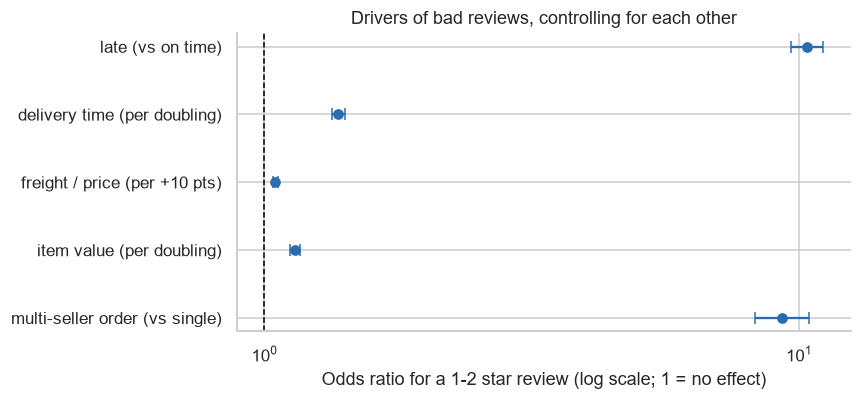

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8))
r = res.iloc[::-1]
ax.errorbar(r["odds_ratio"], range(len(r)), xerr=[r["odds_ratio"] - r["ci_low"], r["ci_high"] - r["odds_ratio"]],
            fmt="o", color=BLUE, capsize=4)
ax.axvline(1, color="black", ls="--", lw=1); ax.set_xscale("log")
ax.set_yticks(range(len(r))); ax.set_yticklabels(r.index)
ax.set_xlabel("Odds ratio for a 1-2 star review (log scale; 1 = no effect)")
ax.set_title("Drivers of bad reviews, controlling for each other")
save("05_odds_ratios.png")
KEY["or_late"] = float(res.loc["late (vs on time)", "odds_ratio"])
KEY["or_multi_seller"] = float(res.loc["multi-seller order (vs single)", "odds_ratio"])
KEY["or_freight"] = float(res.loc["freight / price (per +10 pts)", "odds_ratio"])
KEY["or_delivery_time"] = float(res.loc["delivery time (per doubling)", "odds_ratio"])

In [12]:
print(named("07_satisfaction_drivers.sql", "slow_but_on_time_vs_slow_and_late").to_string(index=False))
print()
print(named("07_satisfaction_drivers.sql", "score_by_order_complexity").to_string(index=False))

               group_name  orders  avg_score  pct_1_2_star
   took 21+ days AND late    5481       2.13          66.5
took 21+ days but on time    6735       3.92          15.4

sellers_in_order  orders  avg_score  late_pct
        1 seller   94302       4.17       6.8
      2+ sellers    1258       2.86       1.0


## 4. Where does revenue concentrate?

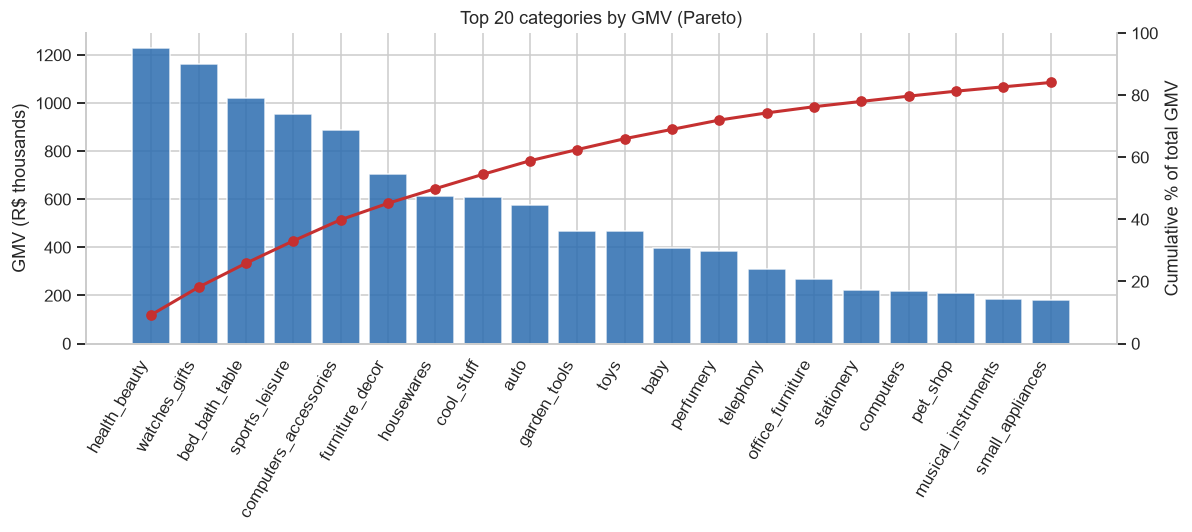

18 of 74 categories generate 80% of GMV


In [13]:
cp = named("05_category_seller_analysis.sql", "category_performance").head(20)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(cp)), cp["gmv"] / 1e3, color=BLUE, alpha=.85)
ax.set_xticks(range(len(cp))); ax.set_xticklabels(cp["category"], rotation=60, ha="right")
ax.set_ylabel("GMV (R$ thousands)")
ax2 = ax.twinx(); ax2.plot(range(len(cp)), cp["cumulative_pct"], color=RED, marker="o", lw=2)
ax2.set_ylim(0, 100); ax2.set_ylabel("Cumulative % of total GMV"); ax2.grid(False); ax2.spines["right"].set_visible(True)
ax.set_title("Top 20 categories by GMV (Pareto)")
save("06_category_pareto.png")
pa = named("05_category_seller_analysis.sql", "pareto_summary").iloc[0]
KEY["categories_total"], KEY["categories_for_80pct"] = int(pa["total_categories"]), int(pa["categories_for_80pct_gmv"])
print(f"{int(pa['categories_for_80pct_gmv'])} of {int(pa['total_categories'])} categories generate 80% of GMV")

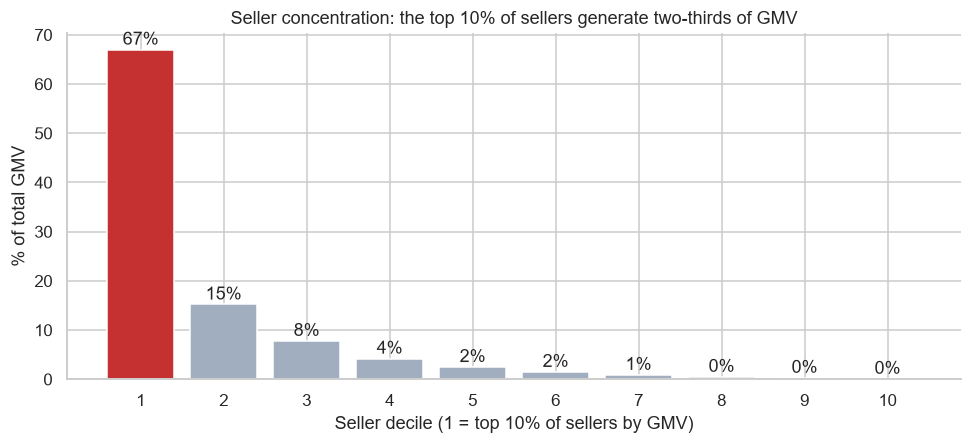

{'seller_state': 'SP', 'sellers': 1751, 'pct_of_sellers': 59.5, 'gmv': 8486328.0, 'pct_of_gmv': 64.4}


In [14]:
sc = named("05_category_seller_analysis.sql", "seller_concentration_deciles")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(sc["decile"], sc["pct_of_gmv"], color=[RED if d == 1 else GREY for d in sc["decile"]])
for d, v in zip(sc["decile"], sc["pct_of_gmv"]):
    ax.text(d, v + 1, f"{v:.0f}%", ha="center")
ax.set_xticks(sc["decile"]); ax.set_xlabel("Seller decile (1 = top 10% of sellers by GMV)"); ax.set_ylabel("% of total GMV")
ax.set_title("Seller concentration: the top 10% of sellers generate two-thirds of GMV")
save("07_seller_deciles.png")
KEY["top_decile_seller_gmv_pct"] = float(sc.loc[sc.decile == 1, "pct_of_gmv"].iloc[0])
geo = named("05_category_seller_analysis.sql", "seller_geography").iloc[0]
KEY["sp_seller_pct"], KEY["sp_gmv_pct"] = float(geo["pct_of_sellers"]), float(geo["pct_of_gmv"])
print(geo.to_dict())

## 5. Customers: acquisition-led growth

In [15]:
pf = named("06_customer_rfm.sql", "purchase_frequency")
KEY["one_time_customers_pct"] = float(pf.loc[pf.orders_placed == "1", "pct_customers"].iloc[0])
KEY["repeat_customers_pct"] = round(100 - KEY["one_time_customers_pct"], 2)
nv = named("06_customer_rfm.sql", "new_vs_returning_revenue")
KEY["returning_revenue_pct_avg"] = float(nv["returning_revenue_pct"].mean())
d2 = named("06_customer_rfm.sql", "days_to_second_purchase").iloc[0]
KEY["median_days_to_2nd"], KEY["pct_2nd_within_24h"] = float(d2["median_days"]), float(d2["pct_within_24h"])
print(pf.to_string(index=False)); print()
print(f"Returning customers = {KEY['returning_revenue_pct_avg']:.1f}% of monthly revenue on average (no upward trend)")
print(d2.to_dict())

orders_placed  customers  pct_customers  total_spend  pct_of_revenue
            1      90307          97.00   12454423.0            94.5
            2       2562           2.75     628326.0             4.8
           3+        227           0.24      97029.0             0.7

Returning customers = 2.5% of monthly revenue on average (no upward trend)
{'repeat_customers': 2789.0, 'avg_days': 80.0, 'median_days': 29.0, 'pct_within_24h': 30.5, 'pct_within_30d': 50.5, 'pct_after_180d': 17.1}


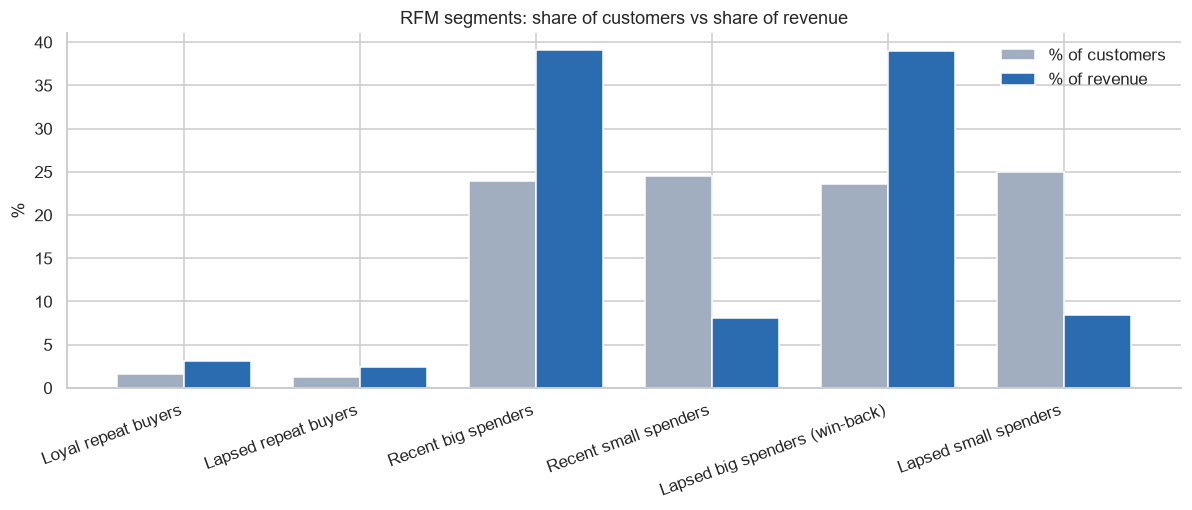

,segment,customers,pct_customers,revenue,pct_revenue,avg_spend,avg_recency_days,avg_orders
0,1 Loyal repeat buyers,1534,1.6,405765.0,3.1,265.0,115.0,2.14
1,2 Lapsed repeat buyers,1255,1.3,319591.0,2.4,255.0,353.0,2.08
2,3 Recent big spenders,22232,23.9,5149225.0,39.1,232.0,114.0,1.00
3,4 Recent small spenders,22782,24.5,1070526.0,8.1,47.0,114.0,1.00
4,5 Lapsed big spenders (win-back),21985,23.6,5134035.0,39.0,234.0,365.0,1.00
5,6 Lapsed small spenders,23308,25.0,1100637.0,8.4,47.0,365.0,1.00


In [16]:
rf = named("06_customer_rfm.sql", "rfm_segment_summary")
rf["label"] = rf["segment"].str[2:]
x = np.arange(len(rf)); w = .38
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - w/2, rf["pct_customers"], w, color=GREY, label="% of customers")
ax.bar(x + w/2, rf["pct_revenue"], w, color=BLUE, label="% of revenue")
ax.set_xticks(x); ax.set_xticklabels(rf["label"], rotation=20, ha="right"); ax.set_ylabel("%")
ax.set_title("RFM segments: share of customers vs share of revenue")
ax.legend(frameon=False)
save("08_rfm_segments.png")
wb = rf[rf["segment"].str.contains("win-back")].iloc[0]
KEY["winback_customers"], KEY["winback_revenue_pct"] = int(wb["customers"]), float(wb["pct_revenue"])
rf.drop(columns="label")

In [17]:
# Does a bad FIRST order reduce the chance of a second one? (Jan-Jun 2017 first-order cohort: equal observation time)
cohort = q("""
WITH firsts AS (
  SELECT customer_unique_id, review_score,
         ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY purchased_at) AS n, purchased_at
  FROM v_analysis_orders),
c AS (SELECT * FROM firsts WHERE n = 1 AND purchased_at < TIMESTAMP '2017-07-01' AND review_score IS NOT NULL),
t AS (SELECT customer_unique_id, count(*) AS total_orders FROM v_analysis_orders GROUP BY 1)
SELECT CASE WHEN c.review_score <= 2 THEN 'bad first review (1-2)' WHEN c.review_score >= 4 THEN 'good first review (4-5)' END AS grp,
       count(*) AS customers, sum(CASE WHEN t.total_orders >= 2 THEN 1 ELSE 0 END) AS repeaters
FROM c JOIN t USING (customer_unique_id)
WHERE c.review_score <> 3
GROUP BY 1""")
cohort["repeat_rate_pct"] = (100 * cohort["repeaters"] / cohort["customers"]).round(2)
tab = np.array([[r.repeaters, r.customers - r.repeaters] for r in cohort.itertuples()])
chi2, p, _, _ = stats.chi2_contingency(tab)
print(cohort.to_string(index=False)); print(f"\nChi-square p-value = {p:.3f}")
KEY["repeat_bad_first"] = float(cohort.loc[cohort.grp.str.startswith("bad"), "repeat_rate_pct"].iloc[0])
KEY["repeat_good_first"] = float(cohort.loc[cohort.grp.str.startswith("good"), "repeat_rate_pct"].iloc[0])
KEY["repeat_chi2_p"] = float(p)

                    grp  customers  repeaters  repeat_rate_pct
 bad first review (1-2)       1504       71.0             4.72
good first review (4-5)      10770      553.0             5.13

Chi-square p-value = 0.534


## 6. Save headline numbers (the README quotes these, nothing is typed by hand)

In [18]:
(ROOT / "outputs" / "key_numbers.json").write_text(json.dumps(KEY, indent=2))
print(json.dumps(KEY, indent=2))

{
  "yoy_gmv_growth_pct": 141.1,
  "yoy_orders_growth_pct": 139.9,
  "gmv_total": 13179778.0,
  "gmv_2018_monthly_min": 826437.0,
  "gmv_2018_monthly_max": 977545.0,
  "black_friday_orders": 1147,
  "typical_day_orders_oct_nov17": 152.0,
  "late_pct": 6.79,
  "avg_delivery_days": 12.5,
  "avg_promised_days": 23.6,
  "pct_week_early": 78.9,
  "seller_handling_days": 2.82,
  "transit_days": 9.37,
  "monthly_corr_late_vs_score": -0.9154847914990804,
  "cross_state_pct_orders": 64.0,
  "cross_state_days": 15.2,
  "same_state_days": 7.9,
  "score_late": 2.270617748510505,
  "score_ontime": 4.291157408445651,
  "mean_diff": -2.020539659935146,
  "mw_p": 0.0,
  "mw_p_note": "below 1e-300",
  "prob_superiority": 0.819091955553608,
  "n_late": 6378,
  "n_ontime": 89182,
  "or_late": 10.368,
  "or_multi_seller": 9.301,
  "or_freight": 1.047,
  "or_delivery_time": 1.375,
  "categories_total": 74,
  "categories_for_80pct": 18,
  "top_decile_seller_gmv_pct": 67.0,
  "sp_seller_pct": 59.5,
  "sp_gmv